<a href="https://colab.research.google.com/github/angelfrancomorales/INFO648/blob/main/Problem_Set_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INFO 648 Homework 2: Descriptive Statistics and Earnings Analysis**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('cps_with_education.csv')

print('Dataset shape:', df.shape)
print('\nEducation categories:')
print(df['education'].value_counts())

Dataset shape: (1048575, 8)

Education categories:
education
Some College               235069
NIU / Child                201544
Master's                   174611
Associate's                135032
Graduate / Professional    103554
Less than HS               103000
Bachelor's                  81761
High School                 14004
Name: count, dtype: int64


**Part A: Descriptive Statistics for Weekly Earnings**

In [18]:
earnweek = df['EARNWEEK2']

# Tukey Five-Number Summary
tukey = {
    'Minimum':  earnweek.min(),
    'Q1 (25th percentile)': earnweek.quantile(0.25),
    'Median (50th percentile)': earnweek.median(),
    'Q3 (75th percentile)': earnweek.quantile(0.75),
    'Maximum': earnweek.max()
}

print('=== Tukey Five-Number Summary — EARNWEEK2 ===')
for k, v in tukey.items():
    print(f'  {k}: {v:,.2f}')

print('\n=== Central Tendency & Spread ===')
print(f'  Mean:               {earnweek.mean():,.2f}')
print(f'  Median:             {earnweek.median():,.2f}')
print(f'  Standard Deviation: {earnweek.std():,.2f}')

=== Tukey Five-Number Summary — EARNWEEK2 ===
  Minimum: 0.00
  Q1 (25th percentile): 0.00
  Median (50th percentile): 2,220.00
  Q3 (75th percentile): 999,999.99
  Maximum: 999,999.99

=== Central Tendency & Spread ===
  Mean:               489,806.89
  Median:             2,220.00
  Standard Deviation: 499,796.07


In [19]:
df = df[df['EARNWEEK2'] < 999999]

print('Rows after removing missing earnings:', len(df))

Rows after removing missing earnings: 535081


In [20]:
df = df[df['EARNWEEK2'] > 0]

print('Rows after removing zero earnings:', len(df))

Rows after removing zero earnings: 94374


**Turkey Summary:** This summary tells us that the data for weekly earnings is skewed to the right. There is a gap between the median and max of 2,885 which comfirms a long upper trail. The IQR of 950 shows the 50% of workers.

**Standard Deviation:** The Trukey summary gives us the shape and center of the bulk of the data, but it does not quantify how far indicidual obvservations stray from the average. The standard deviation is directly influenced by the small group of high eraning outliers.

**Part B: Education Based Subsets**

In [21]:
college_grads = df[df['education'] == "Bachelor's"].copy()
grad_students = df[df['education'] == "Master's"].copy()

print('=== Subset Sizes ===')
print(f"  college_grads (Bachelor's): {len(college_grads):,} observations")
print(f"  grad_students (Master's):   {len(grad_students):,} observations")

=== Subset Sizes ===
  college_grads (Bachelor's): 10,202 observations
  grad_students (Master's):   23,944 observations


**Part B:** Documentation

- **college_grads**: Filtered to rows where `education == "Bachelor's"` —
respondents whose highest degree is a four-year bachelor's degree.
**10,202 observations.**

- **grad_students**: Filtered to rows where `education == "Master's"` —
respondents whose highest degree is a master's degree.
**23,944 observations.**

**Part C: Compare Earning Distribution**

In [22]:
def earnings_summary(label, subset):
    ew = subset['EARNWEEK2']
    print(f'=== {label} — EARNWEEK2 ===')
    print(f'  Mean:               {ew.mean():,.2f}')
    print(f'  Median:             {ew.median():,.2f}')
    print(f'  Std Dev:            {ew.std():,.2f}')
    print(f'  Minimum:            {ew.min():,.2f}')
    print(f'  Q1:                 {ew.quantile(0.25):,.2f}')
    print(f'  Q3:                 {ew.quantile(0.75):,.2f}')
    print(f'  Maximum:            {ew.max():,.2f}')
    print(f'  IQR:                {ew.quantile(0.75) - ew.quantile(0.25):,.2f}')
    print()

earnings_summary("Bachelor's (college_grads)", college_grads)
earnings_summary("Master's (grad_students)", grad_students)

=== Bachelor's (college_grads) — EARNWEEK2 ===
  Mean:               1,002.78
  Median:             876.00
  Std Dev:            597.20
  Minimum:            4.00
  Q1:                 600.00
  Q3:                 1,260.00
  Maximum:            2,885.00
  IQR:                660.00

=== Master's (grad_students) — EARNWEEK2 ===
  Mean:               1,394.86
  Median:             1,230.00
  Std Dev:            784.36
  Minimum:            4.00
  Q1:                 800.00
  Q3:                 1,920.00
  Maximum:            2,885.00
  IQR:                1,120.00



/tmp/ipykernel_12728/3556006828.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=["Bachelor's", "Master's"], patch_artist=True,


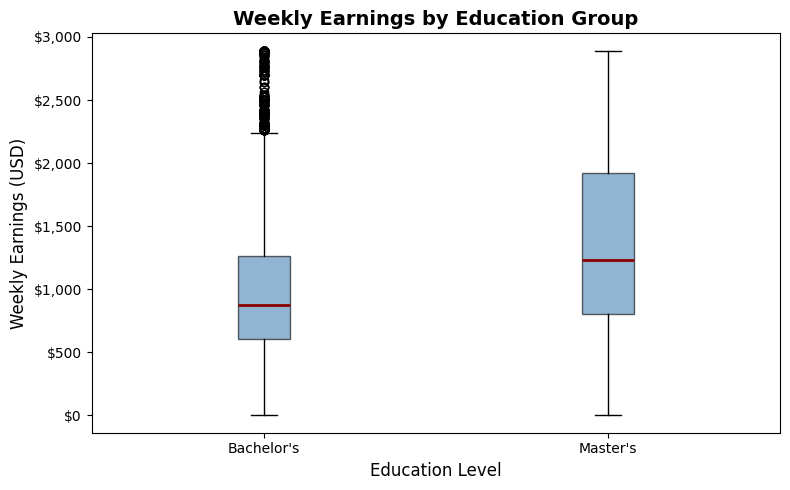

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [
    college_grads['EARNWEEK2'],
    grad_students['EARNWEEK2']
]

ax.boxplot(data_to_plot, labels=["Bachelor's", "Master's"], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='darkred', linewidth=2))

ax.set_title('Weekly Earnings by Education Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Weekly Earnings (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

Part C: Interpretation:

**Typical earnings:** In this plot we can odserve that the Master's degree holders aearn more than the Bachelor's degree holders. The Master's median is 1,230 which is 354 higher than the Bachler's median. Since both distributions are right-skewed themedian is the better measure of earnings.

**Spread of variability:** The Master's grads show more variability in earnings. The IQR for Master's is notably wider than for Bachler's which means that the 50% of Master's earners spans a much broader range. The standard deviation is also showiing that outliers are causing a hih-earning tail which pull the data up.

**Comparison to UHRSWORKT from class:** When we examined hours worked in class, the Tukey five-number summary was much more compressed. Most of the workers clustered tightly around 40 hours per week with little spread between Q1 and Q3. Weekly earnings, by contrast, show a far wider IQR and much longer upper tails in both groups. This suggests that hours worked is fairly consistent across workers, while earnings vary substantially which means that factors beyond hours are driving most of the differences we see.



**Part D: Correlation Between Hours Worked and Earnings**

In [24]:
cg_valid = college_grads[(college_grads['UHRSWORKT'] < 997)].copy()
gs_valid = grad_students[(grad_students['UHRSWORKT'] < 997)].copy()

corr_cg = cg_valid['UHRSWORKT'].corr(cg_valid['EARNWEEK2'])
corr_gs = gs_valid['UHRSWORKT'].corr(gs_valid['EARNWEEK2'])

print('=== Pearson Correlation: UHRSWORKT vs EARNWEEK2 ===')
print(f"  Bachelor's: {corr_cg:.4f}")
print(f"  Master's:   {corr_gs:.4f}")

=== Pearson Correlation: UHRSWORKT vs EARNWEEK2 ===
  Bachelor's: 0.4205
  Master's:   0.3908


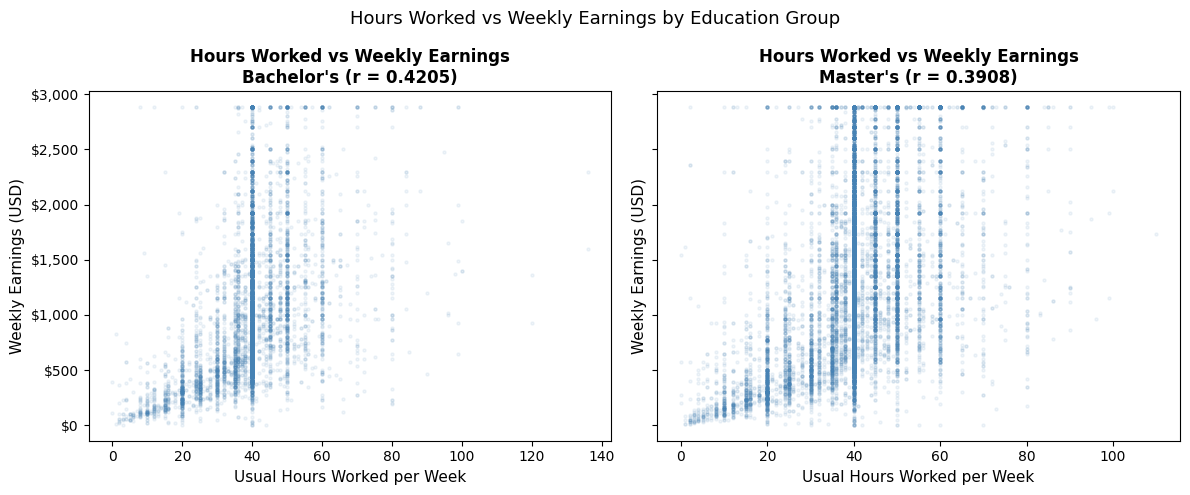

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, data, label, corr in zip(
    axes,
    [cg_valid, gs_valid],
    ["Bachelor's", "Master's"],
    [corr_cg, corr_gs]
):
    ax.scatter(data['UHRSWORKT'], data['EARNWEEK2'],
               alpha=0.08, s=5, color='steelblue')
    ax.set_title(f'Hours Worked vs Weekly Earnings\n{label} (r = {corr:.4f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Usual Hours Worked per Week', fontsize=11)
    ax.set_ylabel('Weekly Earnings (USD)', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Hours Worked vs Weekly Earnings by Education Group', fontsize=13)
plt.tight_layout()
plt.show()

**Part D: Interpretation**

**Streght of the relationship:** The correlation between hours worked and weekly earnings is moderate and postive for both of the groups. This tells us that workers who complete more hours earn more however the relationship is not tight.

**Do hours explain much of the variation in earnings?** No. As shown in the scatter plot, earnings vary from 0 to 2,885. Workers might have the same hours, but different earnings which means that other factors are infleuncing the data such as occupation, industry, or years of experience.

**Part E: Reflection**

The median was the best descriptive statistic for comparing the earnings of both groups. Both education groups are right-skewed. The meidan provides a better picture of what a typical worker earns without being pulled upwards by the outliers. The difference between both groups medians provided a useful gap of 354 to interpret. The standard deviation is useful for understanding the spread, but its being affected by the outliers which makes comparrisons harder to interpret. The final correlation in Part D was interesting, but it still did not provide any specific distinctions between the Master's and Bachelor's groups from one another.